# 1.1 Simple Perceptron

Predictions: [0 0 0 1]


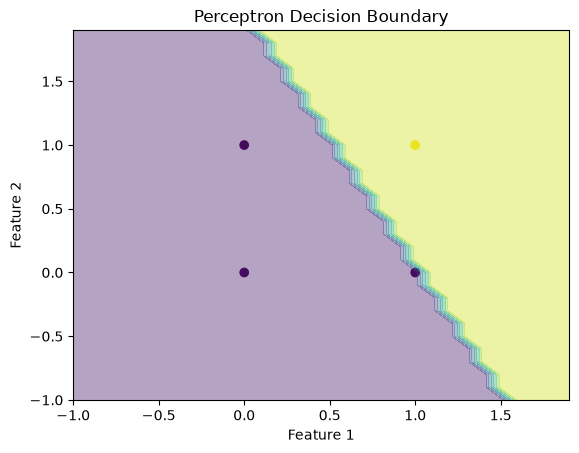

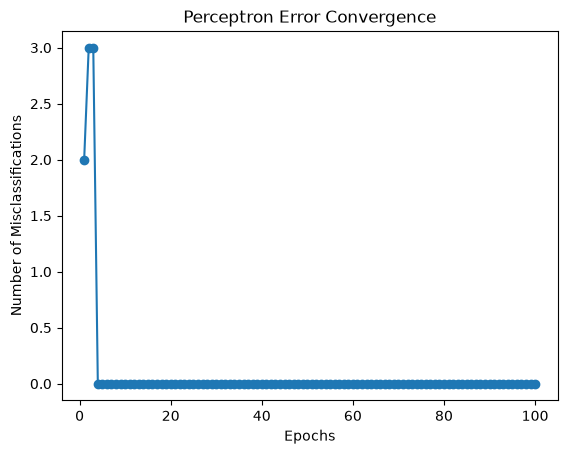

Final weights: [0.2 0.1]
Final bias: -0.20000000000000004


In [1]:
import numpy as np
import matplotlib.pyplot as plt

class Perceptron:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.errors = []
    
    def fit(self, X, y):
        n_features = X.shape[1]
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.errors = []
        for _ in range(self.n_iters):
            errors = 0
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = self.activation_function(linear_output)
                # Perceptron update rule
                update = self.learning_rate * (y[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update
                errors += int(update != 0.0)
            self.errors.append(errors)
                
    def activation_function(self, x):
        return np.where(x >= 0, 1, 0)
    
    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        return self.activation_function(linear_output)
    
    def plot_decision_boundary(self, X, y):
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis')
        x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.1), np.arange(x2_min, x2_max, 0.1))    
        Z = self.predict(np.c_[xx1.ravel(), xx2.ravel()])
        Z = Z.reshape(xx1.shape)
        plt.contourf(xx1, xx2, Z, alpha=0.4, cmap="viridis")
        plt.xlabel("Feature 1")
        plt.ylabel("Feature 2")
        plt.title("Perceptron Decision Boundary")
    
# Example data: AND logic gate
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])  # AND logic output
# y = np.array([0, 1, 1, 1])  # OR logic output
# y = np.array([0, 1, 1, 0])  # XOR logic output


# Create and train Perceptron
perceptron = Perceptron(learning_rate=0.1, n_iters=100)
perceptron.fit(X, y)

# Test the Perceptron
predictions = perceptron.predict(X)
print(f"Predictions: {predictions}")

# Plot decision boundary
perceptron.plot_decision_boundary(X, y)
plt.show()

# Plot error convergence
plt.plot(range(1, len(perceptron.errors) + 1), perceptron.errors, marker="o")
plt.xlabel("Epochs")
plt.ylabel("Number of Misclassifications")
plt.title("Perceptron Error Convergence")
plt.show()

# Print final weights and bias
print(f"Final weights: {perceptron.weights}")
print(f"Final bias: {perceptron.bias}")

# 1.2 Multilayer Perceptron (MLP)

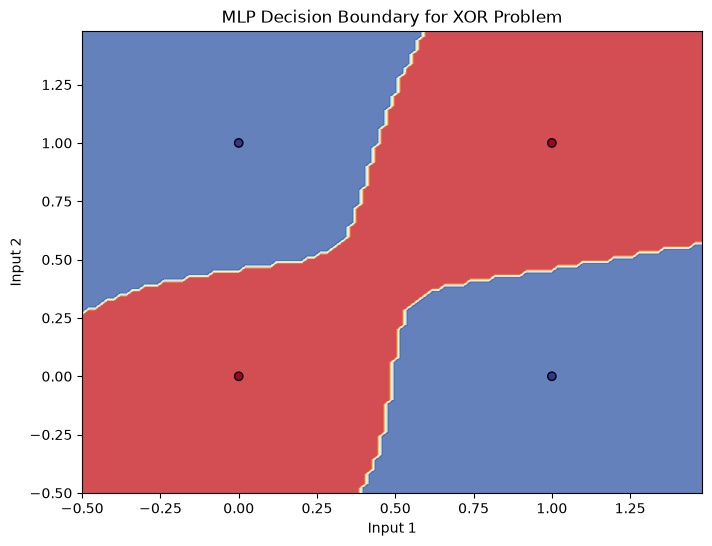

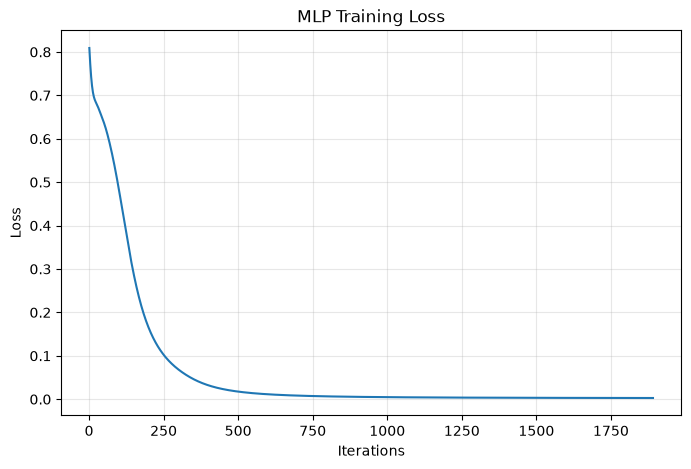

Predictions: [0 1 1 0]
Accuracy: 1.0
Confusion Matrix:
[[2 0]
 [0 2]]
Model Architecture:
Number of layers: 3
Neurons per layer (input, hidden, output): [2, 4, 1]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# XOR dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])  # XOR logic output

# Create MLP classifier
mlp = MLPClassifier(
    hidden_layer_sizes=(4,),
    max_iter=10000,
    activation="tanh",
    solver="adam",
    learning_rate_init=0.01,
    tol=1e-6,
    n_iter_no_change=200,
    random_state=42,
    verbose=False,
)

# Train the MLP
mlp.fit(X, y)

# Make predictions
predictions = mlp.predict(X)

# Calculate accuracy
accuracy = accuracy_score(y, predictions)

# Generate confusion matrix
cm = confusion_matrix(y, predictions)

# Plot decision boundary
def plot_decision_boundary(X, y, model):
    h = 0.02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors="black")
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.title("MLP Decision Boundary for XOR Problem")
    plt.show()

plot_decision_boundary(X, y, mlp)

# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(mlp.loss_curve_) + 1), mlp.loss_curve_)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("MLP Training Loss")
plt.grid(True, alpha=0.3)
plt.show()

# Print results
print(f"Predictions: {predictions}")
print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(cm)
print("Model Architecture:")
layer_sizes = [X.shape[1], *mlp.hidden_layer_sizes, mlp.n_outputs_]
print(f"Number of layers: {mlp.n_layers_}")
print(f"Neurons per layer (input, hidden, output): {layer_sizes}")

# 1.3 Gradient descent (GD)

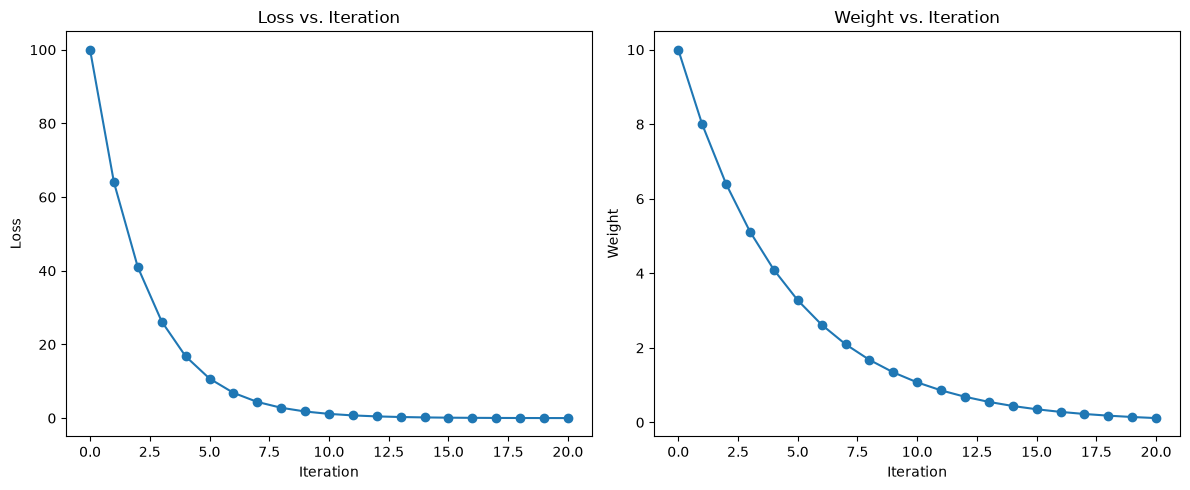

Initial weight: 10.00
Final weight: 0.12
Initial loss: 100.00
Final loss: 0.01


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def loss_function(w):
    """Quadratic loss function: f(w) = w^2"""
    return w**2

def gradient(w):
    """Derivative of the loss function: f'(w) = 2w"""
    return 2 * w

def gradient_descent(initial_w, learning_rate, n_iterations):
    """Perform gradient descent optimization"""
    w = initial_w
    weights = [w]
    losses = [loss_function(w)]
    for i in range(n_iterations):
        grad = gradient(w)
        w = w - learning_rate * grad
        weights.append(w)
        losses.append(loss_function(w))
    return weights, losses

def plot_results(weights, losses):
    """Plot the optimization results"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    # Plot loss curve
    ax1.plot(range(len(losses)), losses, marker='o')
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Loss")
    ax1.set_title("Loss vs. Iteration")
    # Plot weight trajectory
    ax2.plot(range(len(weights)), weights, marker='o')
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel("Weight")
    ax2.set_title("Weight vs. Iteration")
    plt.tight_layout()
    plt.show()
    
# Gradient Descent parameters
initial_w = 10
learning_rate = 0.1
n_iterations = 20

# Perform Gradient Descent
weights, losses = gradient_descent(initial_w, learning_rate, n_iterations)

# Plot results
plot_results(weights, losses)
print(f"Initial weight: {weights[0]:.2f}")
print(f"Final weight: {weights[-1]:.2f}")
print(f"Initial loss: {losses[0]:.2f}")
print(f"Final loss: {losses[-1]:.2f}")

# 1.4 Momentum optimizer 

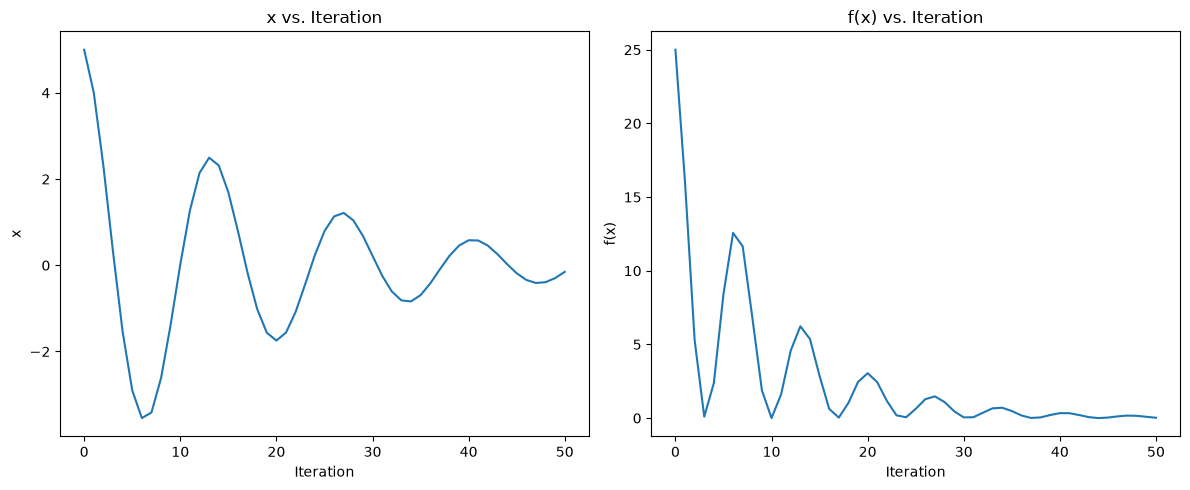

Final x: -0.15249214569569455
Final f(x): 0.023253854498876934


In [4]:
import numpy as np
import matplotlib.pyplot as plt

def quadratic_function(x):
    return x**2

def quadratic_gradient(x):
    return 2*x

def momentum_optimizer(start_x, learning_rate, momentum, num_iterations):
    x = start_x
    velocity = 0
    x_history, f_history = [x], [quadratic_function(x)]
    for _ in range(num_iterations):
        grad = quadratic_gradient(x)
        velocity = momentum * velocity - learning_rate * grad
        x = x + velocity
        x_history.append(x)
        f_history.append(quadratic_function(x))
    return x, x_history, f_history

# Set hyperparameters
start_x = 5.0
learning_rate = 0.1
momentum = 0.9
num_iterations = 50

# Run momentum optimizer
final_x, x_history, f_history = momentum_optimizer(start_x, learning_rate, momentum, num_iterations)

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(num_iterations + 1), x_history)

plt.title("x vs. Iteration")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.subplot(1, 2, 2)
plt.plot(range(num_iterations + 1), f_history)
plt.title("f(x) vs. Iteration")
plt.xlabel("Iteration")
plt.ylabel("f(x)")
plt.tight_layout()
plt.show()
print(f"Final x: {final_x}")
print(f"Final f(x): {quadratic_function(final_x)}")

# 1.5 RMSprop optimizer

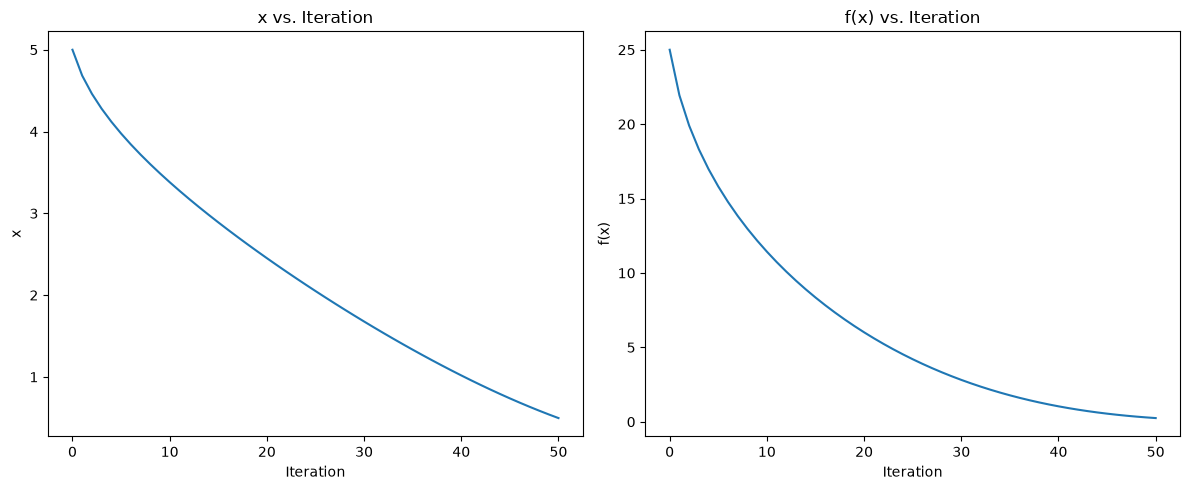

Final x: 0.49652330208741985
Final f(x): 0.24653538951579518


In [5]:
import numpy as np
import matplotlib.pyplot as plt

def quadratic_function(x):
    return x**2

def quadratic_gradient(x):
    return 2*x

def rmsprop(start_x, learning_rate, beta, num_iterations):
    x = start_x
    x_history, f_history = [x], [quadratic_function(x)]
    v = 0
    epsilon = 1e-8
    for _ in range(num_iterations):
        grad = quadratic_gradient(x)
        v = beta * v + (1 - beta) * (grad**2)
        x = x - learning_rate * grad / (np.sqrt(v) + epsilon)
        x_history.append(x)
        f_history.append(quadratic_function(x))
    return x, x_history, f_history

# Set hyperparameters
start_x = 5.0
learning_rate = 0.1
beta = 0.9
num_iterations = 50

# Run RMSprop
final_x, x_history, f_history = rmsprop(start_x, learning_rate, beta, num_iterations)

# Plotting
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(num_iterations + 1), x_history)
plt.title("x vs. Iteration")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.subplot(1, 2, 2)
plt.plot(range(num_iterations + 1), f_history)
plt.title("f(x) vs. Iteration")
plt.xlabel("Iteration")
plt.ylabel("f(x)")
plt.tight_layout()
plt.show()
print(f"Final x: {final_x}")
print(f"Final f(x): {quadratic_function(final_x)}")

# 1.6 Adam optimizer

Expected:   [0 1 1 0]
Predicted:  [0 1 1 0]
Training accuracy: 1.00
Training confusion matrix:
[[2 0]
 [0 2]]


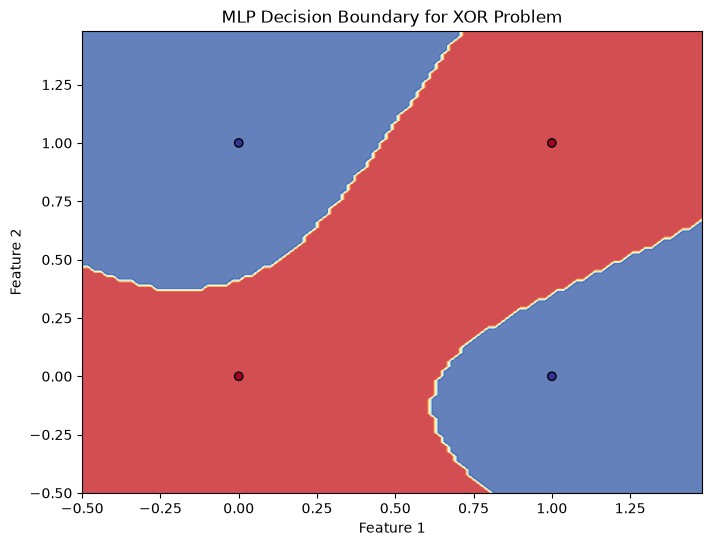

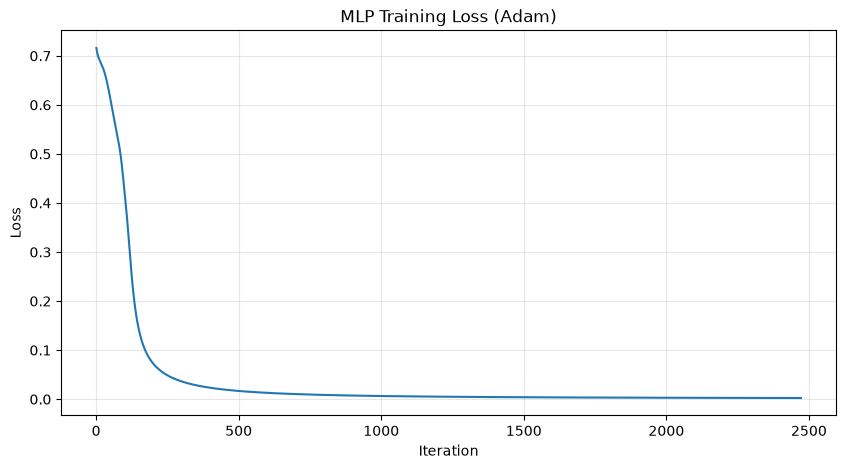

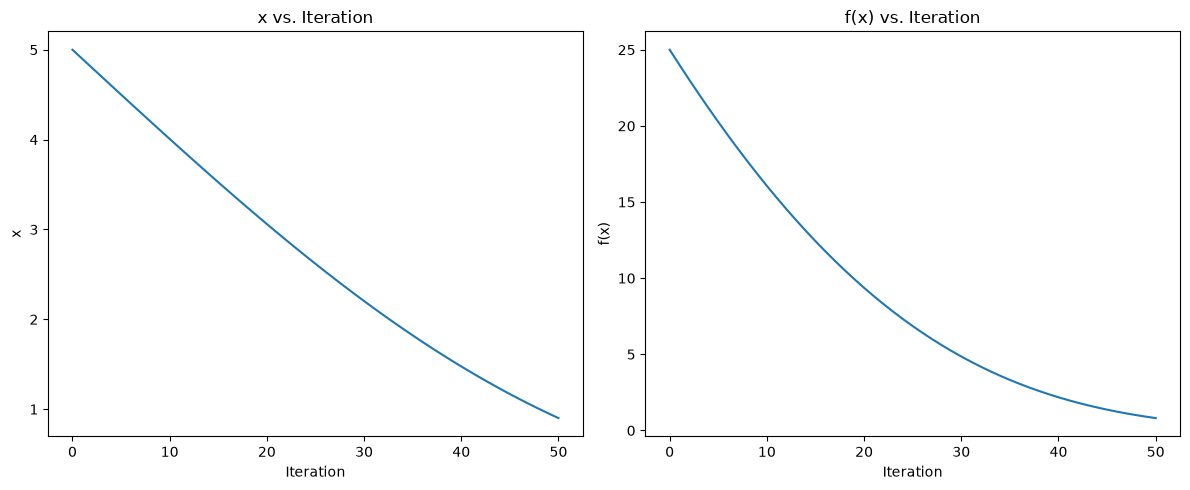

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# XOR truth table
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])

# Train on all four combinations to demonstrate the XOR truth table.
# This reports training accuracy, not generalization to unseen data.
mlp = MLPClassifier(
    hidden_layer_sizes=(4, 2),
    max_iter=10000,
    solver="adam",
    activation="tanh",
    random_state=42,
    learning_rate_init=0.01,
    tol=1e-6,
    n_iter_no_change=200,
)

mlp.fit(X, y)

# Evaluate the learned XOR truth table
predictions = mlp.predict(X)
accuracy = accuracy_score(y, predictions)
cm = confusion_matrix(y, predictions)

print(f"Expected:   {y}")
print(f"Predicted:  {predictions}")
print(f"Training accuracy: {accuracy:.2f}")
print("Training confusion matrix:")
print(cm)

# Visualize the decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor="black")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("MLP Decision Boundary for XOR Problem")
plt.show()

# Plot training loss by iteration
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(mlp.loss_curve_) + 1), mlp.loss_curve_)
plt.title("MLP Training Loss (Adam)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()

# Track Adam optimization of f(x) = x^2
start_x = 5.0
learning_rate = 0.1
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8
num_iterations = 50
adam_x_history = [start_x]
adam_f_history = [start_x**2]
m = 0.0
v = 0.0
x = start_x

for iteration in range(1, num_iterations + 1):
    grad = 2 * x
    m = beta1 * m + (1 - beta1) * grad
    v = beta2 * v + (1 - beta2) * grad**2
    m_hat = m / (1 - beta1**iteration)
    v_hat = v / (1 - beta2**iteration)
    x = x - learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)
    adam_x_history.append(x)
    adam_f_history.append(x**2)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(num_iterations + 1), adam_x_history)
plt.title("x vs. Iteration")
plt.xlabel("Iteration")
plt.ylabel("x")
plt.subplot(1, 2, 2)
plt.plot(range(num_iterations + 1), adam_f_history)
plt.title("f(x) vs. Iteration")
plt.xlabel("Iteration")
plt.ylabel("f(x)")
plt.tight_layout()
plt.show()

# 1.7 Overfitting

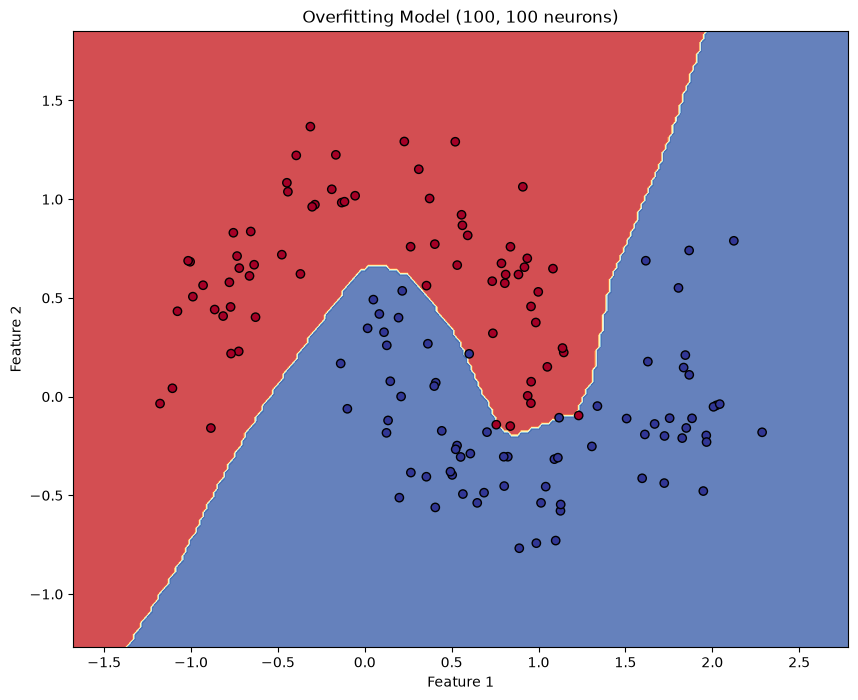

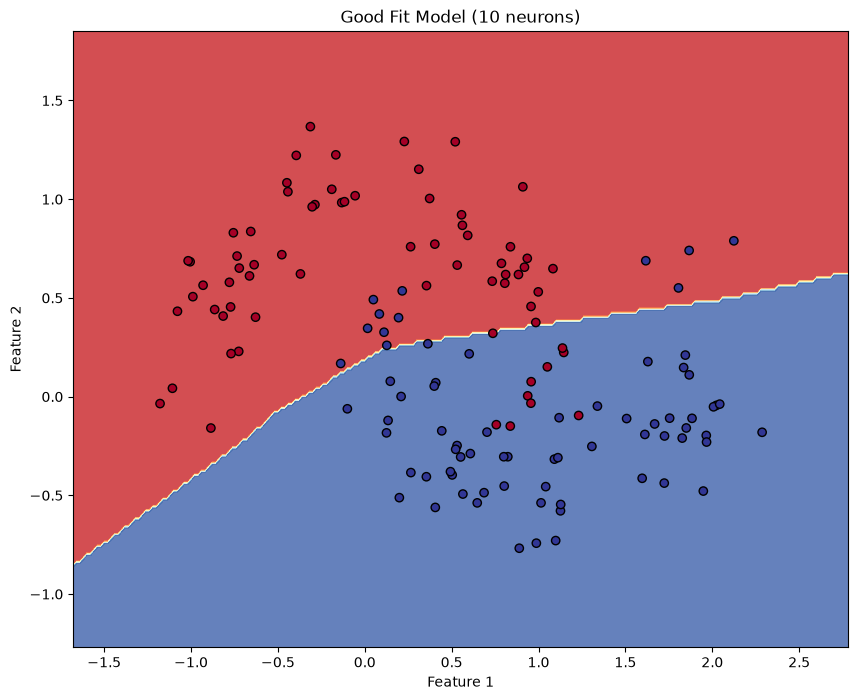

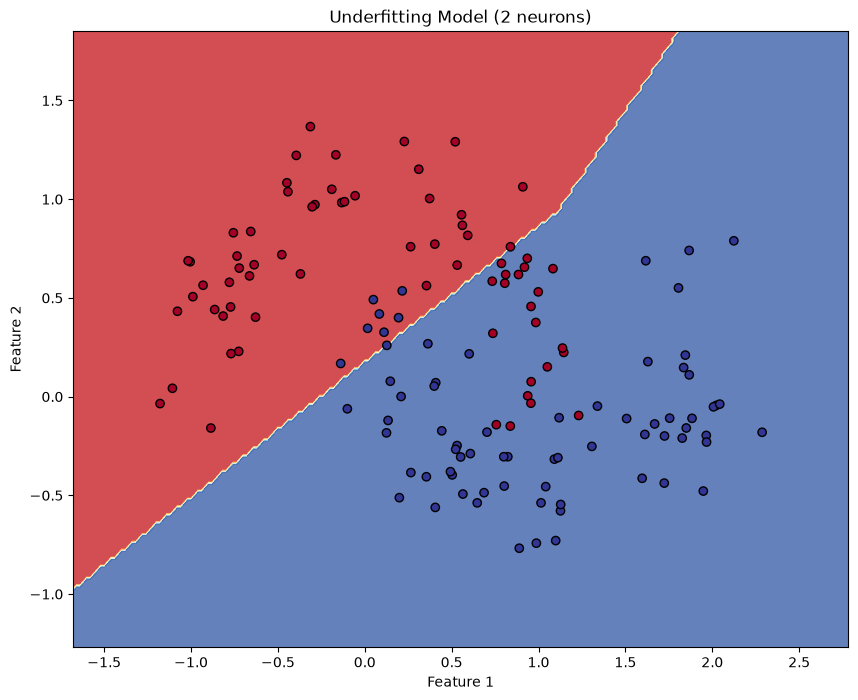

Overfitting Model - Train Accuracy: 0.9714, Test Accuracy: 0.9500
Good Fit Model - Train Accuracy: 0.8429, Test Accuracy: 0.8333
Underfitting Model - Train Accuracy: 0.8000, Test Accuracy: 0.8667


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Generate synthetic data (moons dataset)
X, y = make_moons(n_samples=200, noise=0.20, random_state=42)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Function to plot decision boundary
def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor="black")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()
    
# Train a neural network with too many neurons and no regularization (overfitting)
mlp_overfit = MLPClassifier(hidden_layer_sizes=(100, 100), max_iter=2000, random_state=42)
mlp_overfit.fit(X_train, y_train)

# Train a neural network with appropriate complexity (good fit)
mlp_good = MLPClassifier(hidden_layer_sizes=(10,), max_iter=2000, random_state=42)
mlp_good.fit(X_train, y_train)

# Train a neural network with too few neurons (underfitting)
mlp_underfit = MLPClassifier(hidden_layer_sizes=(2,), max_iter=2000, random_state=42)
mlp_underfit.fit(X_train, y_train)

# Visualize decision boundaries
plot_decision_boundary(X_train, y_train, mlp_overfit, "Overfitting Model (100, 100 neurons)")
plot_decision_boundary(X_train, y_train, mlp_good, "Good Fit Model (10 neurons)")
plot_decision_boundary(X_train, y_train, mlp_underfit, "Underfitting Model (2 neurons)")

# Evaluate models
models = [mlp_overfit, mlp_good, mlp_underfit]
model_names = ["Overfitting", "Good Fit", "Underfitting"]

for model, name in zip(models, model_names):
    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    test_accuracy = accuracy_score(y_test, model.predict(X_test))
    print(f"{name} Model - Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")

# 1.8 Underfitting

Underfitted Model - Train Accuracy: 0.8575
Underfitted Model - Test Accuracy: 0.8150


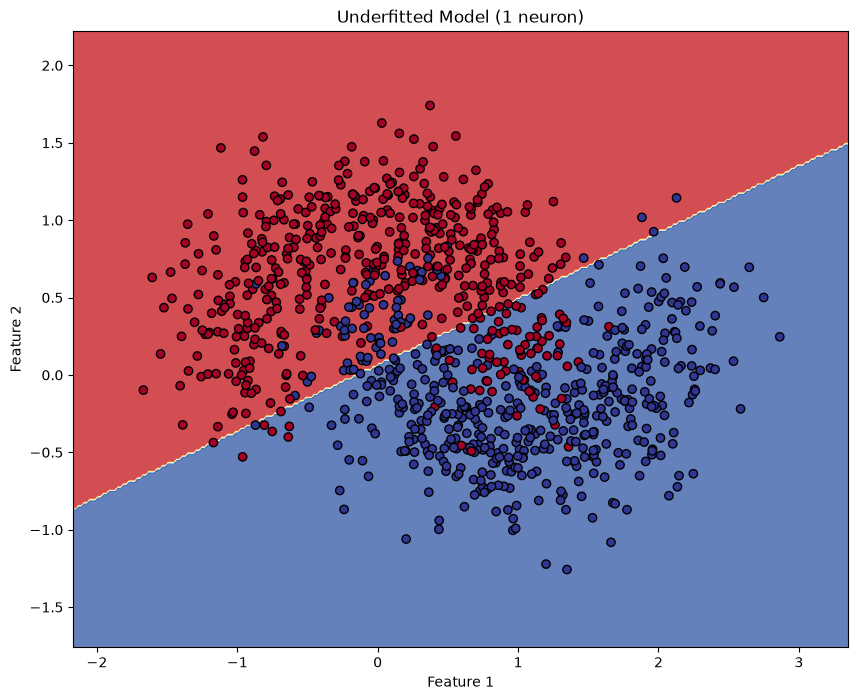

Well-fitted Model - Train Accuracy: 0.9137
Well-fitted Model - Test Accuracy: 0.9400


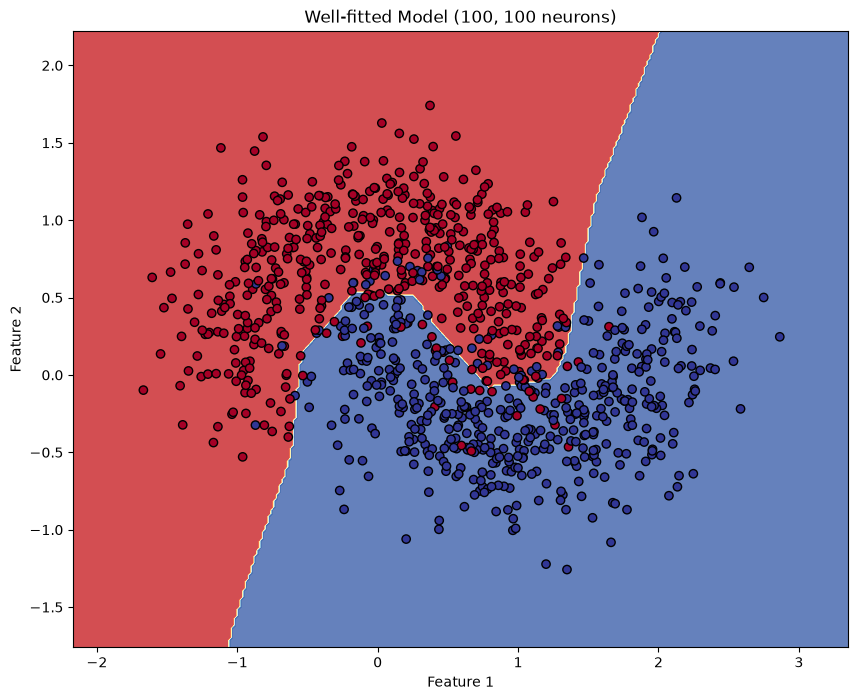

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
# Generate a non-linearly separable dataset
X, y = make_moons(n_samples=1000, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Function to plot decision boundary
def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor="black")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()
    
# Train an underfitted neural network
mlp_underfit = MLPClassifier(hidden_layer_sizes=(1,), max_iter=1000, random_state=42)
mlp_underfit.fit(X_train, y_train)

# Evaluate the underfitted model
train_score = mlp_underfit.score(X_train, y_train)
test_score = mlp_underfit.score(X_test, y_test)
print(f"Underfitted Model - Train Accuracy: {train_score:.4f}")
print(f"Underfitted Model - Test Accuracy: {test_score:.4f}")

# Visualize decision boundary for the underfitted model
plot_decision_boundary(X, y, mlp_underfit, "Underfitted Model (1 neuron)")

# Train a well-fitted neural network for comparison
mlp_well_fit = MLPClassifier(
    hidden_layer_sizes=(100, 100), max_iter=1000, random_state=42
)
mlp_well_fit.fit(X_train, y_train)

# Evaluate the well-fitted model
train_score_well = mlp_well_fit.score(X_train, y_train)
test_score_well = mlp_well_fit.score(X_test, y_test)
print(f"Well-fitted Model - Train Accuracy: {train_score_well:.4f}")
print(f"Well-fitted Model - Test Accuracy: {test_score_well:.4f}")

# Visualize decision boundary for the well-fitted model
plot_decision_boundary(X, y, mlp_well_fit, "Well-fitted Model (100, 100 neurons)")

# 1.9 L1 regularization (Lasso)

Lasso (alpha=0.001):
 MSE: 0.0132
 R2 Score: 0.9980
 Number of non-zero coefficients: 19

Lasso (alpha=0.01):
 MSE: 0.0144
 R2 Score: 0.9978
 Number of non-zero coefficients: 9

Lasso (alpha=0.1):
 MSE: 0.0738
 R2 Score: 0.9888
 Number of non-zero coefficients: 5

Lasso (alpha=1):
 MSE: 3.5573
 R2 Score: 0.4596
 Number of non-zero coefficients: 2

Lasso (alpha=10):
 MSE: 6.5884
 R2 Score: -0.0009
 Number of non-zero coefficients: 0



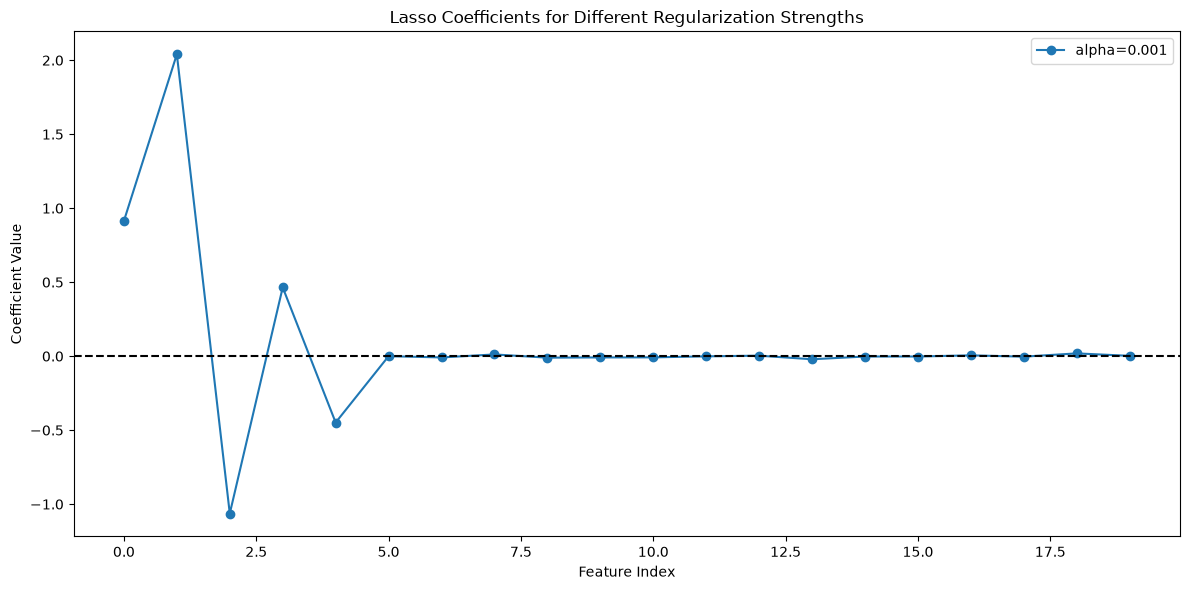

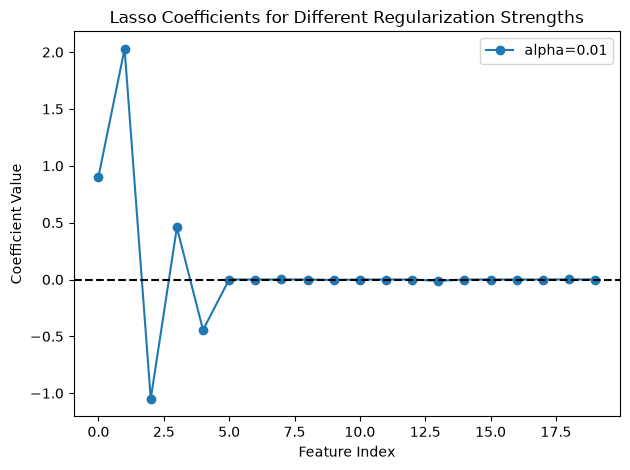

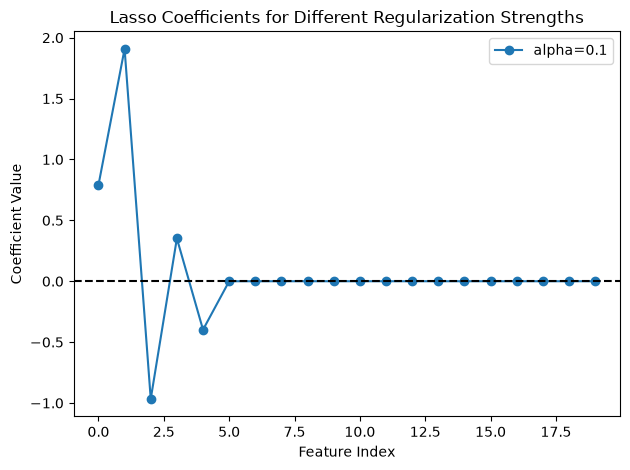

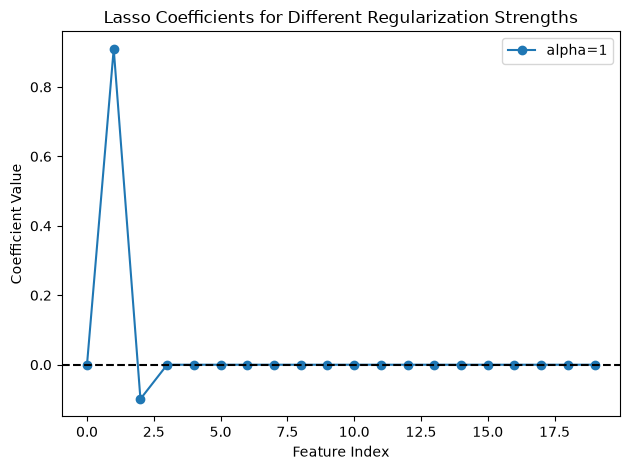

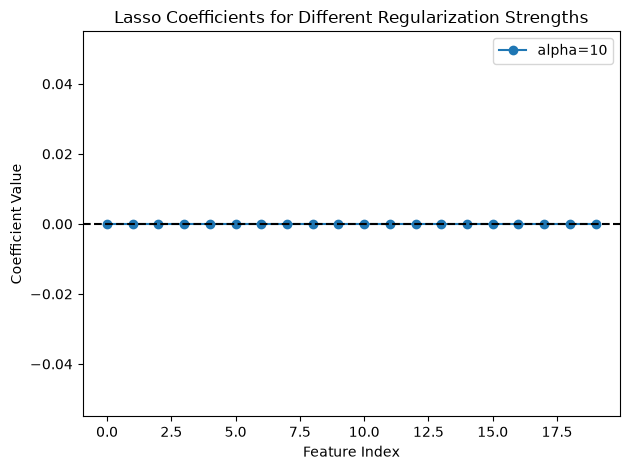

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Generate synthetic data
np.random.seed(42)
X = np.random.randn(100, 20)
true_weights = np.zeros(20)
true_weights[:5] = [1, 2, -1, 0.5, -0.5] # Only first 5 features are relevant
y = np.dot(X, true_weights) + np.random.randn(100) * 0.1

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train models with different L1 regularization strengths
alphas = [0.001, 0.01, 0.1, 1, 10]
models = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, random_state=42)
    lasso.fit(X_train_scaled, y_train)
    models.append(lasso)

# Evaluate models
for i, model in enumerate(models):
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"Lasso (alpha={alphas[i]}):")
    print(f" MSE: {mse:.4f}")
    print(f" R2 Score: {r2:.4f}")
    print(f" Number of non-zero coefficients: {np.sum(model.coef_ != 0)}")
    print()

# Visualize feature importance
plt.figure(figsize=(12, 6))
for i, model in enumerate(models):
    plt.plot(range(20), model.coef_, label=f'alpha={alphas[i]}', marker='o')
    plt.axhline(y=0, color='k', linestyle='--')
    plt.xlabel('Feature Index')
    plt.ylabel('Coefficient Value')
    plt.title('Lasso Coefficients for Different Regularization Strengths')
    plt.legend()
    plt.tight_layout()
    plt.show()



# 1.10 L2 regularization (Ridge)

Model without regularization:
Train Accuracy: 0.9125
Test Accuracy: 0.9150
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       100
           1       0.91      0.92      0.92       100

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.91       200
weighted avg       0.92      0.92      0.91       200

Model with L2 regularization:
Train Accuracy: 0.9113
Test Accuracy: 0.9250
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       100
           1       0.92      0.93      0.93       100

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.92       200
weighted avg       0.93      0.93      0.92       200



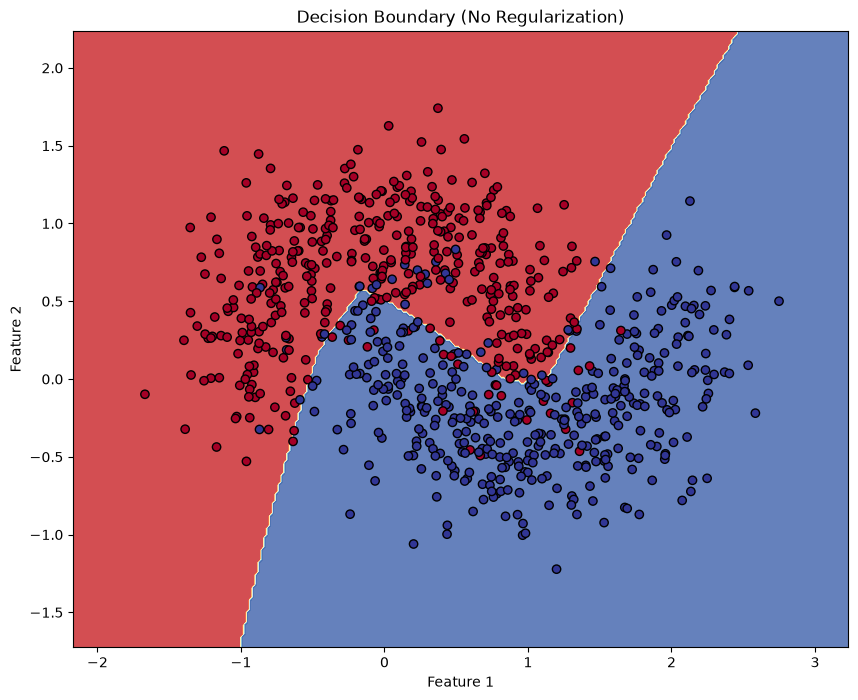

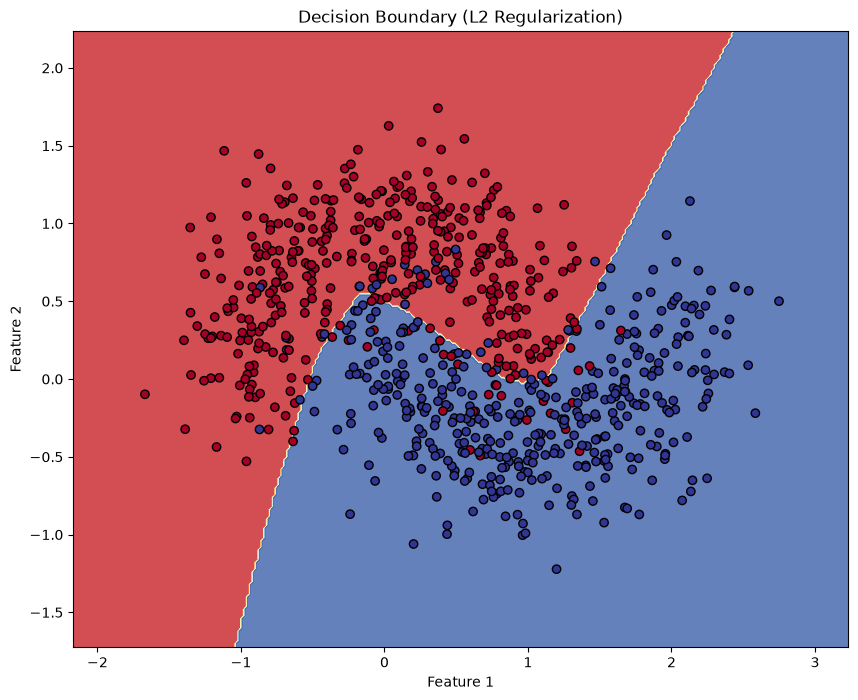

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from sklearn.metrics import accuracy_score, classification_report

# Generate a non-linearly separable dataset
X, y = make_moons(n_samples=1000, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Function to plot decision boundary
def plot_decision_boundary(X, y, model, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor="black")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()
    
# Train a neural network without regularization
mlp_no_reg = MLPClassifier(hidden_layer_sizes=(100,), max_iter=2000, random_state=42)
mlp_no_reg.fit(X_train, y_train)
# Train a neural network with L2 regularization
mlp_l2 = MLPClassifier(hidden_layer_sizes=(100,), alpha=0.01, max_iter=2000, random_state=42)
mlp_l2.fit(X_train, y_train)

# Evaluate both models
def evaluate_model(model, X_train, y_train, X_test, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    train_accuracy = accuracy_score(y_train, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)
    print(f"Train Accuracy: {train_accuracy:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, test_pred))
    
print("Model without regularization:")
evaluate_model(mlp_no_reg, X_train, y_train, X_test, y_test)
print("Model with L2 regularization:")
evaluate_model(mlp_l2, X_train, y_train, X_test, y_test)
# Visualize decision boundaries
plot_decision_boundary(X_train, y_train, mlp_no_reg, "Decision Boundary (No Regularization)")
plot_decision_boundary(X_train, y_train, mlp_l2, "Decision Boundary (L2 Regularization)")

# 1.11 Dropout (neuron deactivation)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0949 
Test Accuracy: 1.0000


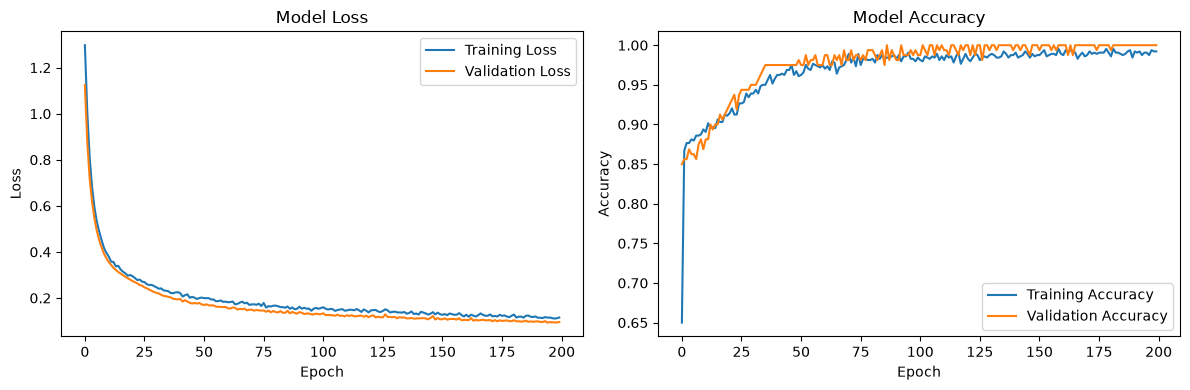

1845/1845 ━━━━━━━━━━━━━━━━━━━━ 1s 396us/step


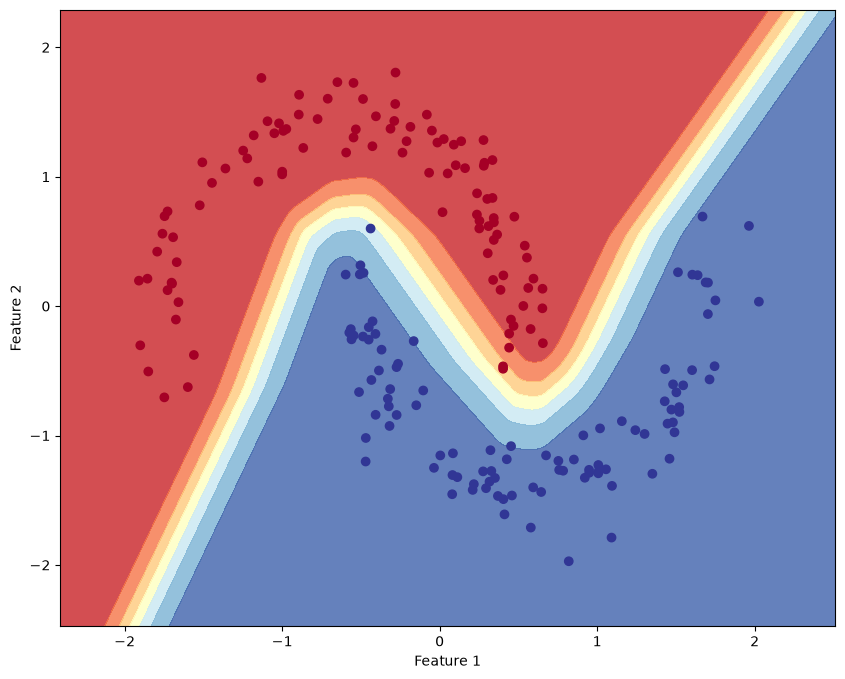

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# Generate synthetic data
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create a neural network with dropout regularization and L2 regularization
model = Sequential(
    [
        Input(shape=(2,)),
        Dense(100, activation="relu", kernel_regularizer=l2(0.01)),
        Dropout(0.3),
        Dense(50, activation="relu", kernel_regularizer=l2(0.01)),
        Dropout(0.3),
        Dense(1, activation="sigmoid"),
    ]
)
# Compile the model
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
# Define early stopping callback
early_stopping = EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)
# Train the model
history = model.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0)

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

# Plot decision boundary
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

plt.figure(figsize=(10, 8))
plot_decision_boundary(model, X_test_scaled, y_test)
plt.show()

# 1.12 Early stop at Keras

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6737 - loss: 0.5888 - val_accuracy: 0.7350 - val_loss: 0.5298
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8263 - loss: 0.4434 - val_accuracy: 0.8150 - val_loss: 0.4508
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8537 - loss: 0.3678 - val_accuracy: 0.8250 - val_loss: 0.4090
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8662 - loss: 0.3294 - val_accuracy: 0.8350 - val_loss: 0.3926
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8800 - loss: 0.3060 - val_accuracy: 0.8550 - val_loss: 0.3790
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8900 - loss: 0.2910 - val_accuracy: 0.8550 - val_loss: 0.3779
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8900 - loss: 0.2799 - val_accuracy: 0.8500 - val_loss: 0.3816
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8938 - loss: 0.2690 - val_accuracy: 0.8700 - 

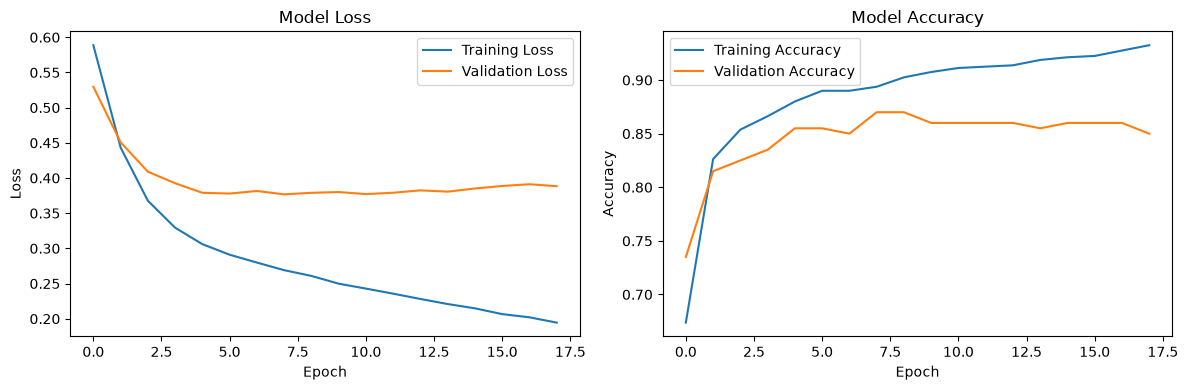

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt

# Generate a sample dataset
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
# Define the model
model = Sequential(
    [
        Input(shape=(20,)),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid"),
    ]
)
# Compile the model
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
# Define early stopping callback
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    min_delta=0.001,
    mode="min",
    restore_best_weights=True,
    verbose=1,
)
# Train the model with early stopping
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1,
)
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# 1.13 Loss functions in deep learning

## 1.13.1 Mean Squared Error (MSE)

Training MSE: 400.83
Test MSE: 446.69
Training R^2: 0.38
Test R^2: 0.35


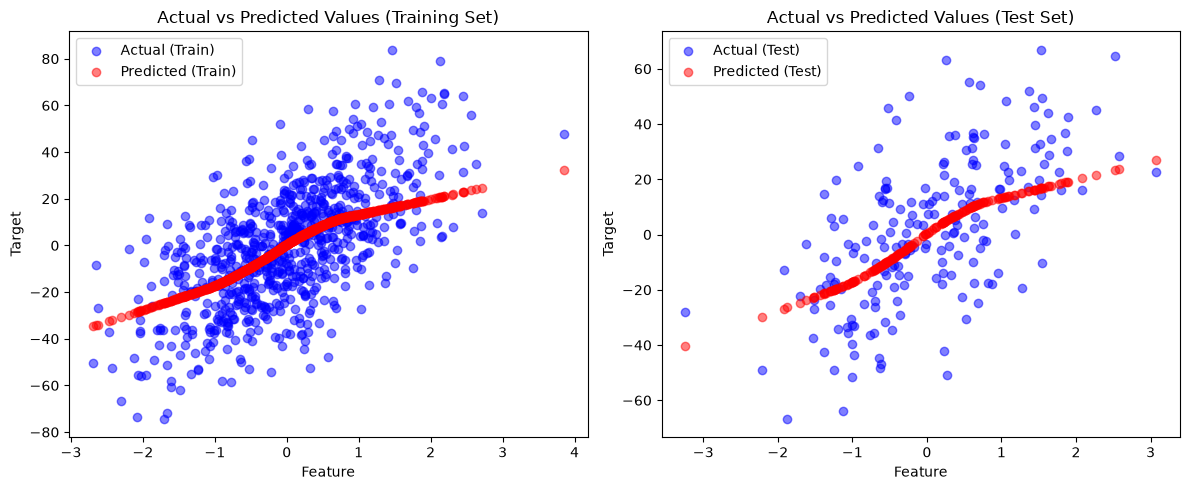

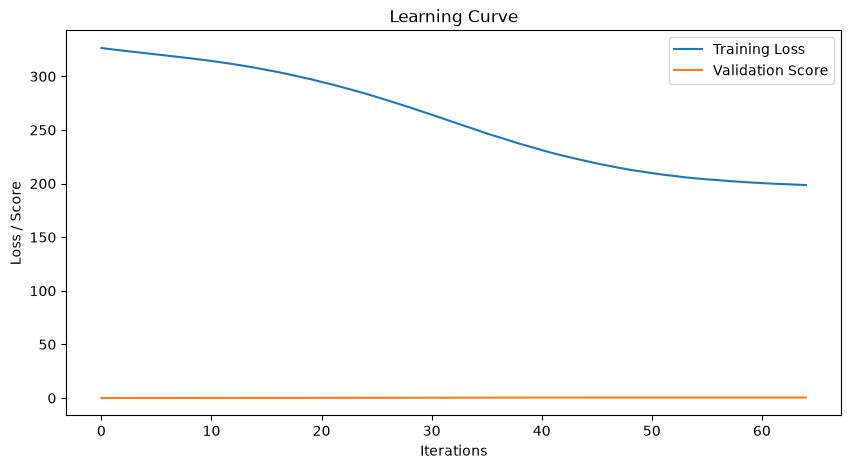

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Generate synthetic regression data
X, y = make_regression(n_samples=1000, n_features=1, noise=20, random_state=42)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Create a simple neural network regressor
mlp = MLPRegressor(
    hidden_layer_sizes=(50, 25),
    max_iter=1000,
    activation="relu",
    solver="adam",
    random_state=42,
    learning_rate_init=0.001,
    early_stopping=True,
)
# Train the model
mlp.fit(X_train_scaled, y_train)

# Make predictions
y_pred_train = mlp.predict(X_train_scaled)
y_pred_test = mlp.predict(X_test_scaled)

# Compute metrics
mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
print(f"Training MSE: {mse_train:.2f}")
print(f"Test MSE: {mse_test:.2f}")
print(f"Training R^2: {r2_train:.2f}")
print(f"Test R^2: {r2_test:.2f}")

# Plot actual vs predicted values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, color="blue", alpha=0.5, label="Actual (Train)")
plt.scatter(X_train, y_pred_train, color="red", alpha=0.5, label="Predicted (Train)")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Actual vs Predicted Values (Training Set)")
plt.legend()
plt.subplot(1, 2, 2)
plt.scatter(X_test, y_test, color="blue", alpha=0.5, label="Actual (Test)")
plt.scatter(X_test, y_pred_test, color="red", alpha=0.5, label="Predicted (Test)")
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Actual vs Predicted Values (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

# Plot learning curve
plt.figure(figsize=(10, 5))
plt.plot(mlp.loss_curve_, label="Training Loss")
plt.plot(mlp.validation_scores_, label="Validation Score")
plt.xlabel("Iterations")
plt.ylabel("Loss / Score")
plt.title("Learning Curve")
plt.legend()
plt.show()

## 1.13.2 Binary cross-entropy loss (log loss)

Binary Cross-Entropy Loss: 0.2332
Accuracy: 0.9300
Confusion Matrix:
[[101   3]
 [ 11  85]]
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.97      0.94       104
           1       0.97      0.89      0.92        96

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.93       200
weighted avg       0.93      0.93      0.93       200



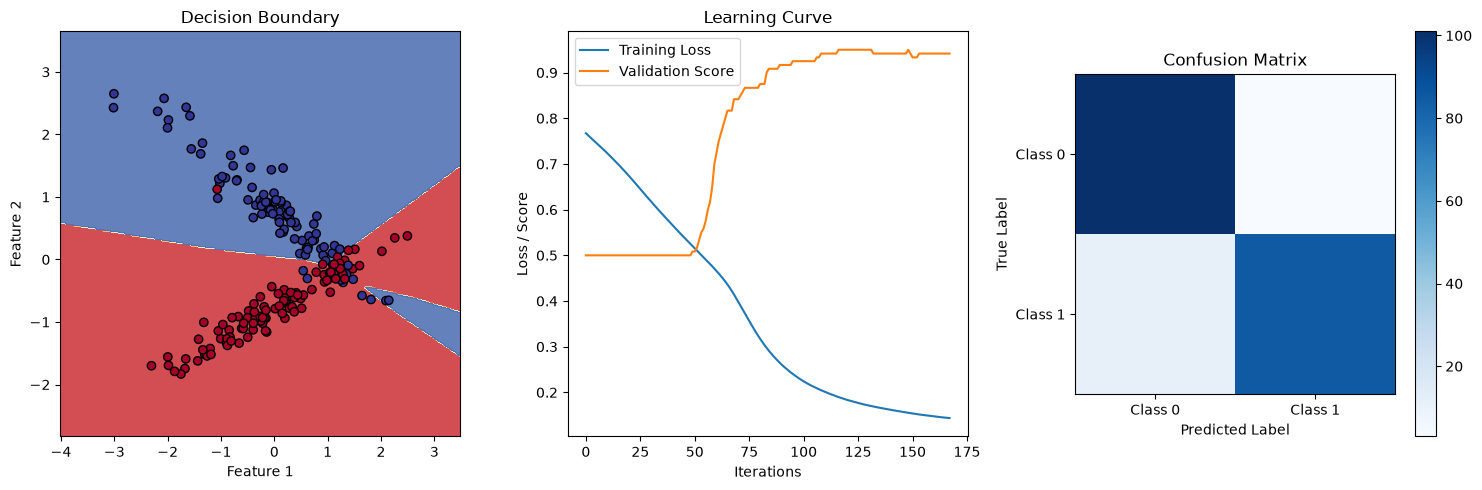

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# Generate synthetic binary classification data
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_classes=2,
    n_clusters_per_class=1,
    n_redundant=0,
    n_informative=2,
    random_state=42,
)
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Create a neural network classifier
mlp = MLPClassifier(
    hidden_layer_sizes=(10, 5),
    activation="relu",
    max_iter=1000,
    solver="adam",
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=50,
    tol=1e-5,
)
# Train the model
mlp.fit(X_train_scaled, y_train)
# Make predictions
y_pred_prob = mlp.predict_proba(X_test_scaled)[:, 1]
y_pred = mlp.predict(X_test_scaled)
# Compute metrics
logloss = log_loss(y_test, y_pred_prob)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
print(f"Binary Cross-Entropy Loss: {logloss:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot decision boundary
def plot_decision_boundary(X, y, model, ax=None):
    h = .02 # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    if ax is None:
        ax = plt.gca()
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor='black')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    return ax

# Plot results
plt.figure(figsize=(15, 5))
plt.subplot(131)
plot_decision_boundary(X_test_scaled, y_test, mlp)
plt.title('Decision Boundary')
plt.subplot(132)
plt.plot(mlp.loss_curve_, label='Training Loss')
plt.plot(mlp.validation_scores_, label='Validation Score')
plt.xlabel('Iterations')
plt.ylabel('Loss / Score')
plt.title('Learning Curve')
plt.legend()
plt.subplot(133)
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Class 0', 'Class 1'])
plt.yticks(tick_marks, ['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

## 1.13.3 Categorical cross-entropy loss

Categorical Cross-Entropy Loss: 0.1381
Accuracy: 0.9648
Confusion Matrix:
[[53  0  0  0  0  0  0  0  0  0]
 [ 0 47  1  0  0  0  1  0  1  0]
 [ 0  1 46  0  0  0  0  0  0  0]
 [ 0  0  2 51  0  1  0  0  0  0]
 [ 0  0  0  0 60  0  0  0  0  0]
 [ 0  0  0  0  1 62  1  0  0  2]
 [ 0  0  0  0  1  0 52  0  0  0]
 [ 0  0  0  0  0  0  0 54  0  1]
 [ 0  2  0  0  0  0  0  0 41  0]
 [ 0  0  0  0  0  1  0  0  3 55]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.94      0.94      0.94        50
           2       0.94      0.98      0.96        47
           3       1.00      0.94      0.97        54
           4       0.97      1.00      0.98        60
           5       0.97      0.94      0.95        66
           6       0.96      0.98      0.97        53
           7       1.00      0.98      0.99        55
           8       0.91      0.95      0.93        43
           9       0.95      0.

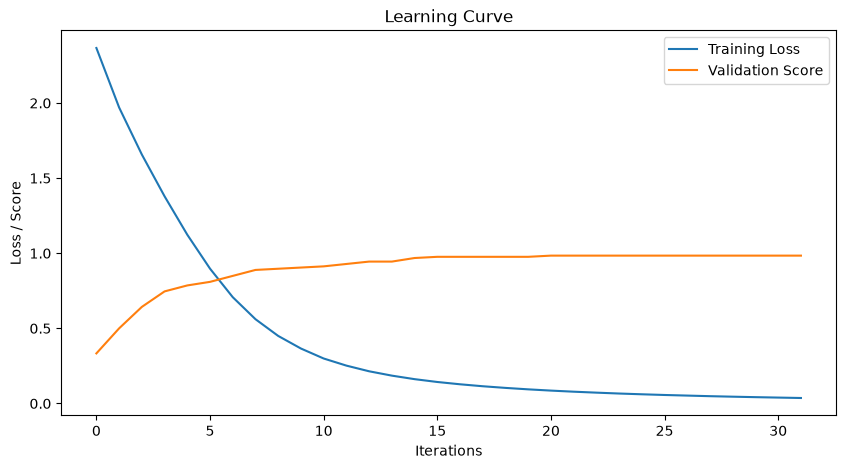

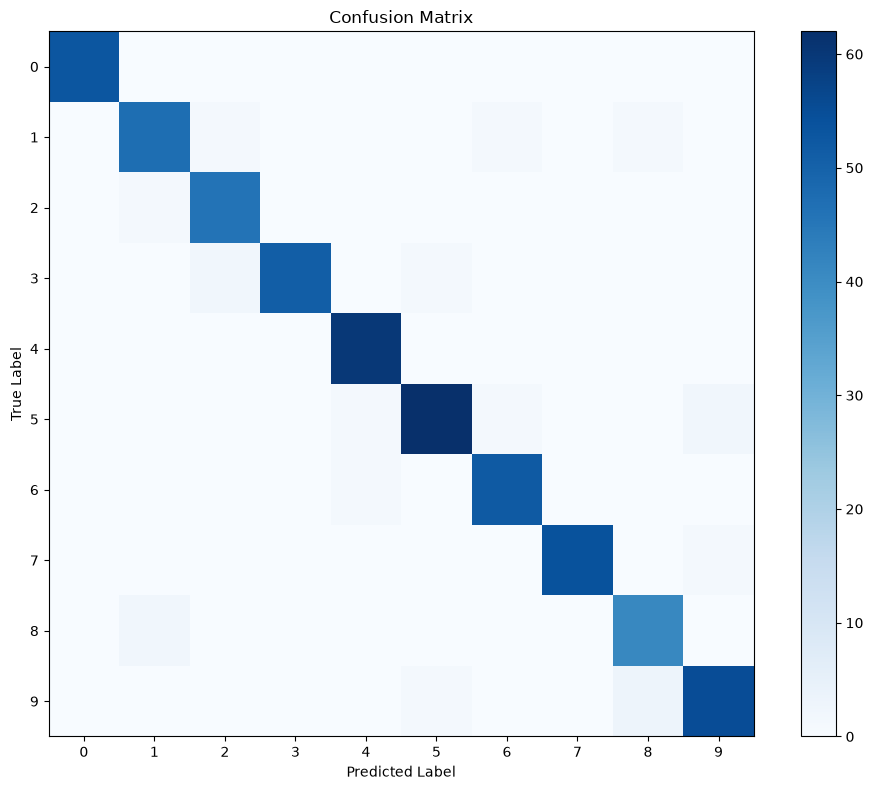

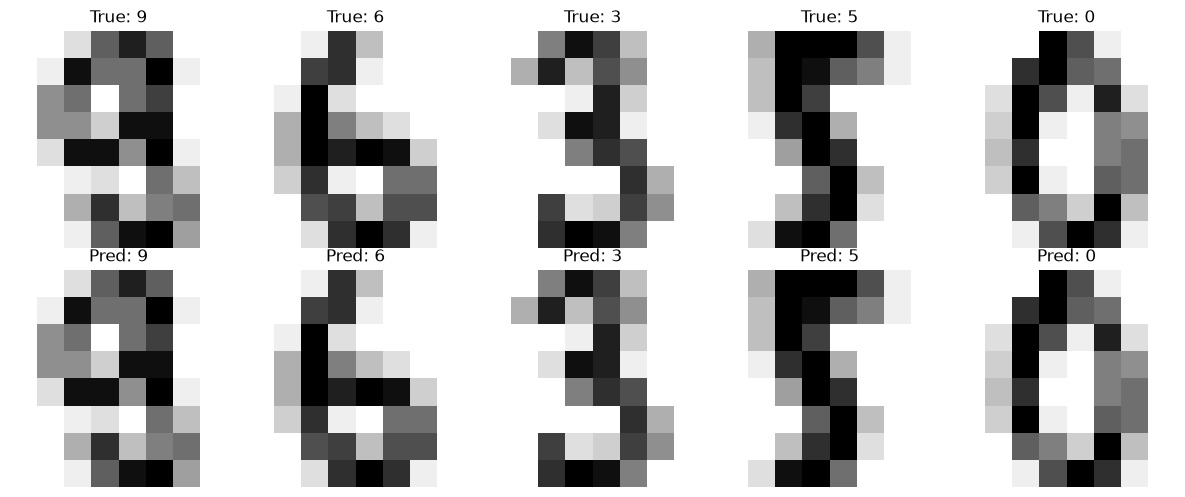

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import log_loss, accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# Load the digits dataset (multi-class classification)
digits = load_digits()
X, y = digits.data, digits.target

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create a neural network classifier for multi-class classification
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation="relu",
    max_iter=1000,
    solver="adam",
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
)

# Train the model
mlp.fit(X_train_scaled, y_train)

# Predict probabilities and compute categorical cross-entropy loss
y_pred_prob = mlp.predict_proba(X_test_scaled)
logloss = log_loss(y_test, y_pred_prob)
print(f"Categorical Cross-Entropy Loss: {logloss:.4f}")

# Compute and display accuracy
y_pred = mlp.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Display confusion matrix and classification report
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Visualize learning curve
plt.figure(figsize=(10, 5))
plt.plot(mlp.loss_curve_, label="Training Loss")
plt.plot(mlp.validation_scores_, label="Validation Score")
plt.xlabel("Iterations")
plt.ylabel("Loss / Score")
plt.title("Learning Curve")
plt.legend()
plt.show()

# Visualize confusion matrix
plt.figure(figsize=(10, 8))
plt.imshow(conf_matrix, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(10)
plt.xticks(tick_marks, digits.target_names)
plt.yticks(tick_marks, digits.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Visualize some predictions
n_samples = 5
fig, axes = plt.subplots(2, n_samples, figsize=(12, 5))

for i in range(n_samples):
    idx = np.random.randint(len(X_test))
    axes[0, i].imshow(X_test[idx].reshape(8, 8), cmap=plt.cm.gray_r)
    axes[0, i].axis('off')
    axes[0, i].set_title(f'True: {y_test[idx]}')
    axes[1, i].imshow(X_test[idx].reshape(8, 8), cmap=plt.cm.gray_r)
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Pred: {y_pred[idx]}')
    
plt.tight_layout()
plt.show()

## 1.13.4 Hinge loss (hinge loss function)

Test Loss: 0.1558
Test Accuracy: 0.9250


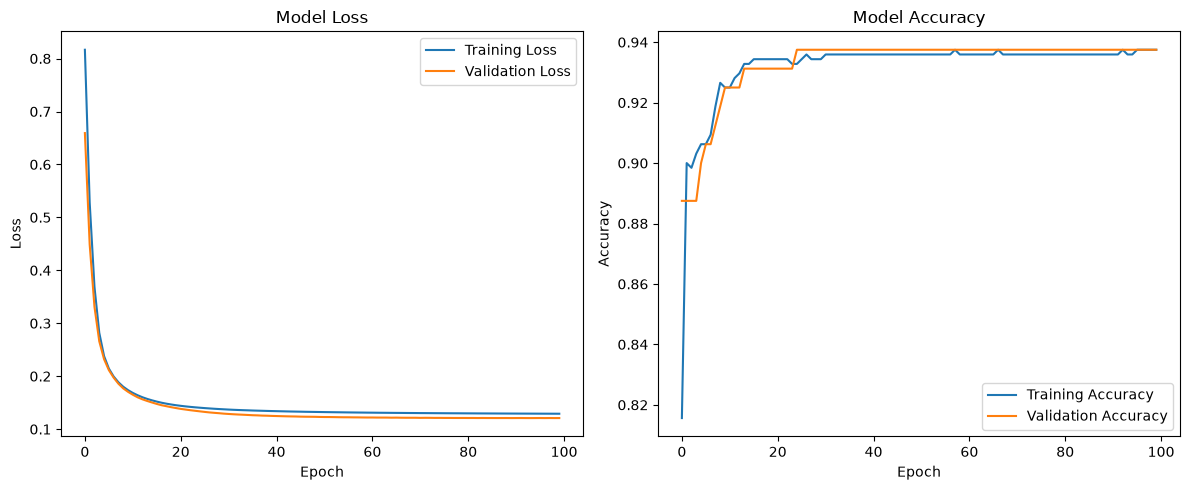

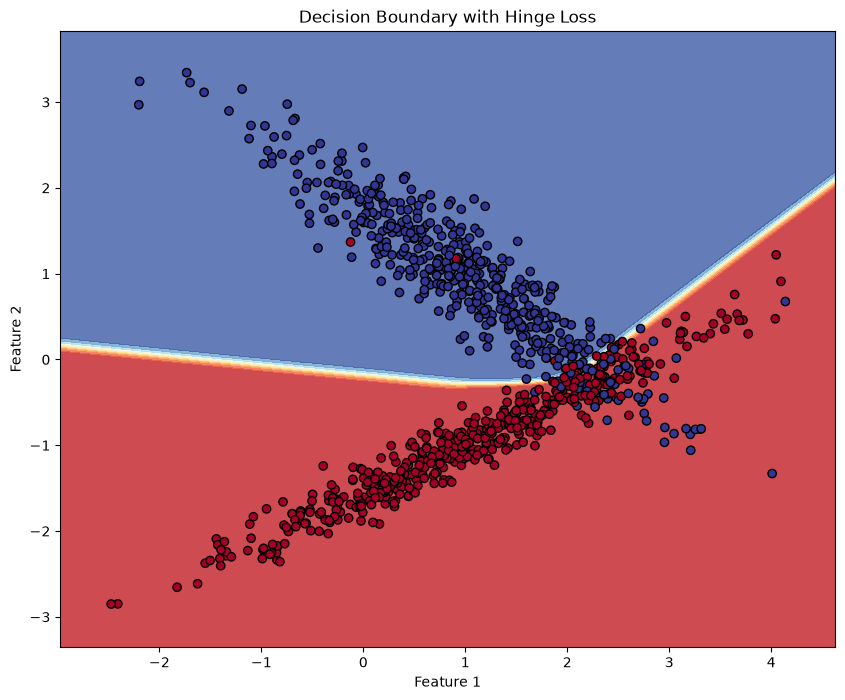

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryAccuracy

# Custom hinge loss function for binary labels (0 and 1)
def hinge_loss(y_true, y_pred):
    y_true = tf.cast(y_true, y_pred.dtype)
    y_true = tf.reshape(2.0 * y_true - 1.0, tf.shape(y_pred))
    return tf.reduce_mean(tf.maximum(1.0 - y_true * y_pred, 0.0), axis=-1)

# Generate binary classification dataset
X, y = make_classification(
    n_samples=1000,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=42,
    n_clusters_per_class=1,
)

# Split the data
tf.keras.utils.set_random_seed(42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create the model
model = Sequential([
    Input(shape=(2,)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="tanh"),
])

# The tanh output is classified at zero; hinge loss converts labels to -1 and 1
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=hinge_loss,
    metrics=[BinaryAccuracy(threshold=0.0)],
)

# Train the model
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0,
)

# Evaluate the model
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Plot decision boundary
def plot_decision_boundary(X, y, model, scaler):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02),
    )
    Z = model.predict(scaler.transform(np.c_[xx.ravel(), yy.ravel()]), verbose=0)
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors="black")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Decision Boundary with Hinge Loss")
    plt.show()

# Plot learning curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history["binary_accuracy"], label="Training Accuracy")
plt.plot(history.history["val_binary_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Plot decision boundary
plot_decision_boundary(X, y, model, scaler)

## 1.13.5 Custom loss function in Keras

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2290.0603 
Test Loss: 2290.0603
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


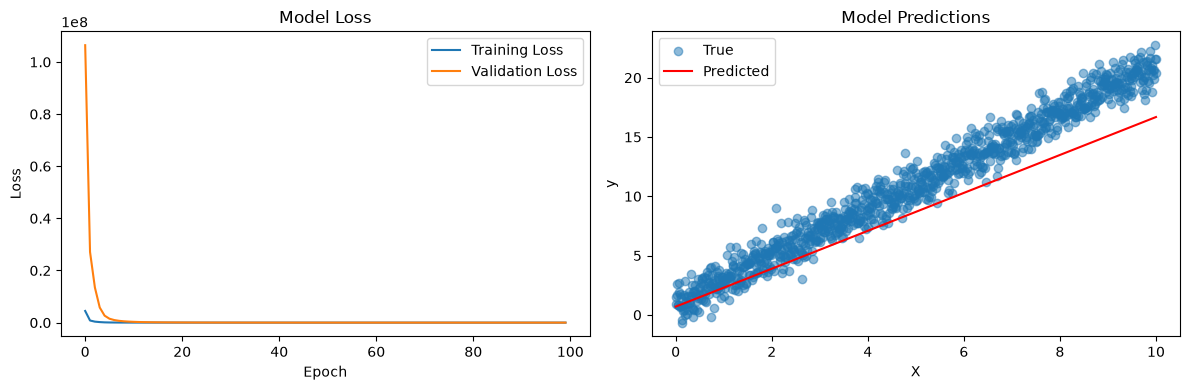

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
import numpy as np
import matplotlib.pyplot as plt

# Custom loss function
def custom_loss(y_true, y_pred):
    # Example: Weighted MSE that penalizes underestimation more heavily
    error = y_true - y_pred
    return K.mean(K.square(error) * K.exp(K.abs(error)), axis=-1)

# Generate sample data
np.random.seed(42)
X = np.linspace(0, 10, 1000).reshape(-1, 1)
y = 2 * X + 1 + np.random.normal(0, 1, X.shape)

# Split data
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Define model
model = keras.Sequential([
    keras.layers.Input(shape=(1,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

# Compile model with custom loss
model.compile(optimizer='adam', loss=custom_loss)

# Train model
history = model.fit(X_train, y_train, epochs=100, validation_split=0.2, verbose=0)

# Evaluate model
test_loss = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")

# Plot results
plt.figure(figsize=(12, 4))

# Plot training history
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot predictions
plt.subplot(1, 2, 2)
y_pred = model.predict(X)
plt.scatter(X, y, alpha=0.5, label='True')
plt.plot(X, y_pred, color='red', label='Predicted')
plt.title('Model Predictions')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()